In [86]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Lab 10 to 14

## Lab 10 Manipulation with Pandas

In [87]:
data = {
    "Name" : ["Swan","Htet","Pyae","Sone"],
    "Age" : [23,25,26,24],
    "IsStudent": [True,False,True,False]
}

df = pd.DataFrame(data)
print(df)

   Name  Age  IsStudent
0  Swan   23       True
1  Htet   25      False
2  Pyae   26       True
3  Sone   24      False


In [88]:
# Checking the first row using .head()
print(f"First two row of the dataframe is \n{df.head(2)}")
print(f"Last row of the dataframe is\n{df.tail(1)}")
print("="*20)
rows, colums = df.shape
print(f"Data Frame has {rows} rows and {colums} colums")
print("="*20)
print(f"Accessing all the name in Dataframe\n{df["Name"]}") # Can also select multiple columns
print("="*20)
# Selecting the row using loc and iloc
print(f"Selecting based on the label using loc\n{df.loc[0:2]}") # row 0 to 2
print(f"Selecting based on the position using iloc\n{df.iloc[0:2]}") # .iloc[0:2,0:2] [row,colums]
print("="*20)
print(f"Filtering all the student\n{df[df["IsStudent"]==True]}")


First two row of the dataframe is 
   Name  Age  IsStudent
0  Swan   23       True
1  Htet   25      False
Last row of the dataframe is
   Name  Age  IsStudent
3  Sone   24      False
Data Frame has 4 rows and 3 colums
Accessing all the name in Dataframe
0    Swan
1    Htet
2    Pyae
3    Sone
Name: Name, dtype: str
Selecting based on the label using loc
   Name  Age  IsStudent
0  Swan   23       True
1  Htet   25      False
2  Pyae   26       True
Selecting based on the position using iloc
   Name  Age  IsStudent
0  Swan   23       True
1  Htet   25      False
Filtering all the student
   Name  Age  IsStudent
0  Swan   23       True
2  Pyae   26       True


In [89]:
print("="*20)
df['IsAdult'] = df['Age']>=18
print(f"Adding the new data to the existing frame\n{df[["Name","IsAdult"]]}")
print("="*20)
print(f"Showing all people\n{df}")
only_student_df = df[df["IsStudent"]==True]
print(f"People list after removing non-student\n{only_student_df}")

Adding the new data to the existing frame
   Name  IsAdult
0  Swan     True
1  Htet     True
2  Pyae     True
3  Sone     True
Showing all people
   Name  Age  IsStudent  IsAdult
0  Swan   23       True     True
1  Htet   25      False     True
2  Pyae   26       True     True
3  Sone   24      False     True
People list after removing non-student
   Name  Age  IsStudent  IsAdult
0  Swan   23       True     True
2  Pyae   26       True     True


In [90]:
print("="*20)
print(f"Sorted according to age\n{df.sort_values("Age",ascending=False)}")
print(f"Means age of the students is {df["Age"].mean()}")

Sorted according to age
   Name  Age  IsStudent  IsAdult
2  Pyae   26       True     True
1  Htet   25      False     True
3  Sone   24      False     True
0  Swan   23       True     True
Means age of the students is 24.5


## 11 CSV manipulation with Pandas

In [91]:
# Reading the csv file
df_csv = pd.read_csv("studentData.csv")
df_csv

,Name,BornYear,IsStudent,Country,Age,Email,CountryCode
0,Swan,2002,True,Myanmar,24,swan@gmail.com,95
1,Htet,2002,True,China,24,NaN,95
2,Pyae,2003,True,Thailand,23,swan@gmail.com,95
3,Bilasj,1993,False,Srilanka,33,bilash@gmail.com,95


In [92]:
# Shape of the data
print(f"Data has the shape of {df_csv.shape}")
# Colums of the data
print(f"Colums are\n{df_csv.columns}")
# Checking Info
print(f"Info of the data frame is\n{df_csv.info()}")

Data has the shape of (4, 7)
Colums are
Index(['Name', 'BornYear', 'IsStudent', 'Country', 'Age', 'Email',
       'CountryCode'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         4 non-null      str  
 1   BornYear     4 non-null      int64
 2   IsStudent    4 non-null      bool 
 3   Country      4 non-null      str  
 4   Age          4 non-null      int64
 5   Email        3 non-null      str  
 6   CountryCode  4 non-null      int64
dtypes: bool(1), int64(3), str(3)
memory usage: 328.0 bytes
Info of the data frame is
None


In [93]:
# Filtering the data who is only 2002 year born / filter person
# print(f"Filter only 2002 year born\n{df_csv[df_csv["BornYear"]==2002]["BornYear"]}")
print(f"Filter only 2002 year born\n{df_csv[df_csv['BornYear'] == 2002][['Name', 'BornYear']]}") # Multiple

Filter only 2002 year born
   Name  BornYear
0  Swan      2002
1  Htet      2002


In [94]:
# Add New Columns 
df_csv["Age"] = 2026 - df_csv["BornYear"]
print(df_csv)
#expose to csv
df_csv.to_csv("studentData.csv",index=False) # many to knows in the constructor
print("New data saved to the csv.")
# Rename column using df_csv.rename() df.rename(columns={"salary": "monthly_salary"}, inplace=True)
# drop using .drop()

     Name  BornYear  IsStudent   Country  Age             Email  CountryCode
0    Swan      2002       True   Myanmar   24    swan@gmail.com           95
1    Htet      2002       True     China   24               NaN           95
2    Pyae      2003       True  Thailand   23    swan@gmail.com           95
3  Bilasj      1993      False  Srilanka   33  bilash@gmail.com           95
New data saved to the csv.


## 12 Handling Missing Values, Duplicate Values, Data Cleaning on Csv

In [95]:
df_csv_to_clean = pd.read_csv("studentData.csv")
print(df_csv_to_clean)

     Name  BornYear  IsStudent   Country  Age             Email  CountryCode
0    Swan      2002       True   Myanmar   24    swan@gmail.com           95
1    Htet      2002       True     China   24               NaN           95
2    Pyae      2003       True  Thailand   23    swan@gmail.com           95
3  Bilasj      1993      False  Srilanka   33  bilash@gmail.com           95


### Checking Missing Value

In [96]:
df_csv_to_clean.isnull().sum()

Name           0
BornYear       0
IsStudent      0
Country        0
Age            0
Email          1
CountryCode    0
dtype: int64

In [97]:
df_csv_to_clean.dropna()
print(df_csv_to_clean)

     Name  BornYear  IsStudent   Country  Age             Email  CountryCode
0    Swan      2002       True   Myanmar   24    swan@gmail.com           95
1    Htet      2002       True     China   24               NaN           95
2    Pyae      2003       True  Thailand   23    swan@gmail.com           95
3  Bilasj      1993      False  Srilanka   33  bilash@gmail.com           95


In [98]:
# Get columns that have at least one null value
# columns_with_null = df_csv_to_clean.columns[df_csv_to_clean.isnull().any()].tolist()
# print(columns_with_null)
print(df_csv_to_clean.columns[df_csv_to_clean.isnull().any()].to_list())

['Email']


### 13 Matplotlib

In [99]:
data_for_visualization = pd.read_csv("studentData.csv")
data_for_visualization

,Name,BornYear,IsStudent,Country,Age,Email,CountryCode
0,Swan,2002,True,Myanmar,24,swan@gmail.com,95
1,Htet,2002,True,China,24,NaN,95
2,Pyae,2003,True,Thailand,23,swan@gmail.com,95
3,Bilasj,1993,False,Srilanka,33,bilash@gmail.com,95


#### Line Plot

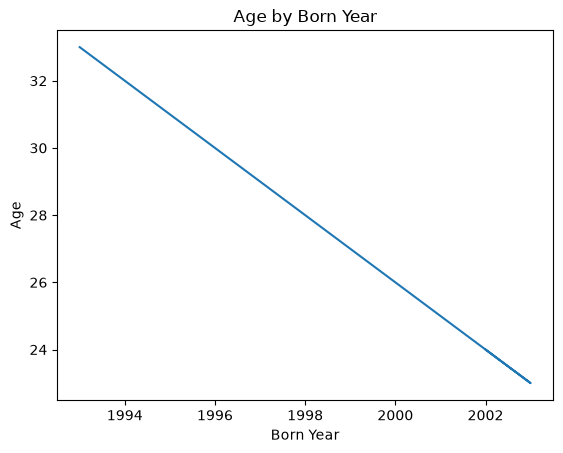

In [101]:
plt.plot(data_for_visualization["BornYear"], data_for_visualization["Age"])

plt.xlabel("Born Year")
plt.ylabel("Age")
plt.title("Age by Born Year")

plt.show()

### Bar Chart

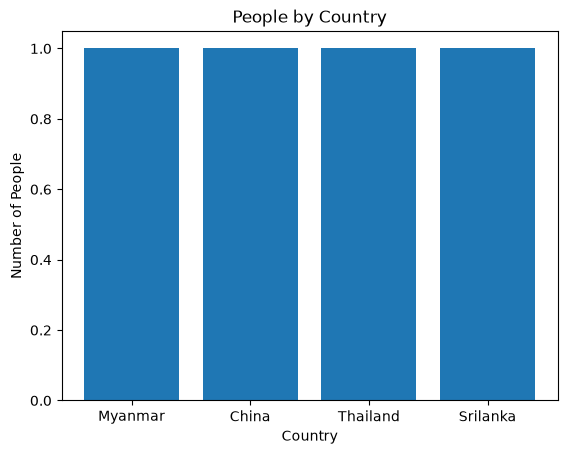

In [102]:
country_counts = data_for_visualization["Country"].value_counts()

plt.bar(country_counts.index, country_counts.values)

plt.xlabel("Country")
plt.ylabel("Number of People")
plt.title("People by Country")

plt.show()

### Scatter Plot

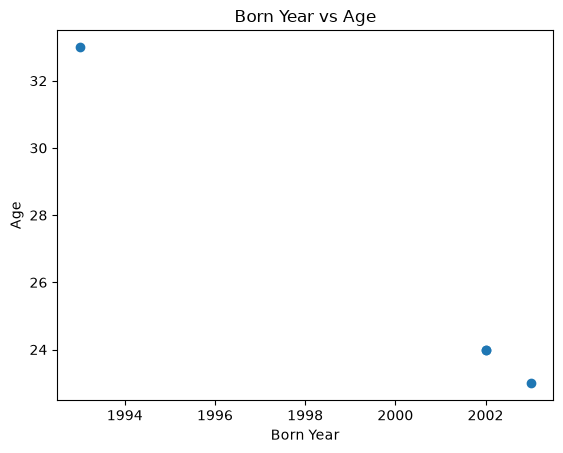

In [103]:
plt.scatter(data_for_visualization["BornYear"], data_for_visualization["Age"])

plt.xlabel("Born Year")
plt.ylabel("Age")
plt.title("Born Year vs Age")

plt.show()

### Histogram

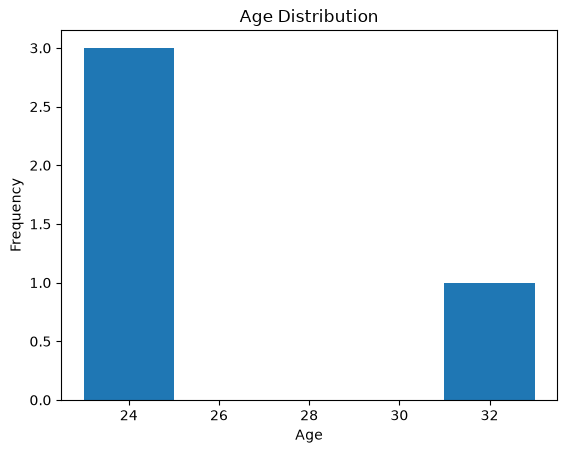

In [104]:
plt.hist(data_for_visualization["Age"], bins=5)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

### Pie Chart

IsStudent
True     3
False    1
Name: count, dtype: int64


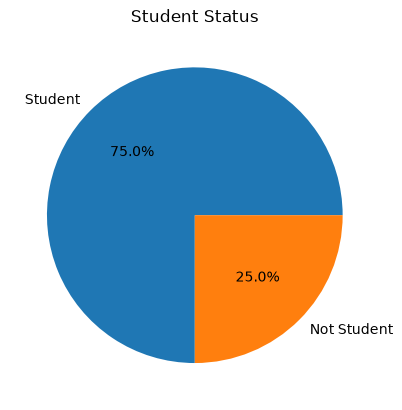

In [106]:
student_counts = data_for_visualization["IsStudent"].value_counts()

print(student_counts)

plt.pie(
    student_counts.values,
    labels=["Student", "Not Student"],
    autopct="%1.1f%%"
)

plt.title("Student Status")

plt.show()

# 14 Labeling the chart